In [32]:
!pip install optuna numba scipy

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import time
import numpy as np
from scipy.stats import truncnorm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    import optuna
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Optuna не установлена. Выполните: %pip install optuna") from exc

try:
    import numba as nb
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Numba не установлена. Выполните: %pip install numba") from exc

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_SCENARIOS_FULL = 10_000
N_SCENARIOS_SEARCH = 1_500
N_TRIALS = 256       
TOP_K_FULL = 48     
BATCH_SIZE = 64
SEED = 42
N_THREADS = min(16, os.cpu_count() or 1)
nb.set_num_threads(N_THREADS)

TIME_TO_PLATEAU = np.float32(2.0)
PLATEAU_ENDS_AT = np.float32(65.0)
MINIMUM_RATE = np.float32(10.0)
OIL_MARGIN = np.float32(2.2241224442773273) 
MAX_YEARS = 50

FACILITY_OPTIONS = np.array([50, 100, 150, 200, 250, 300, 350], dtype=np.float32)
FACILITY_COST_ARR = np.array([70, 130, 180, 220, 250, 270, 280], dtype=np.float32)
FACILITY_VALUES = [50, 100, 150, 200, 250, 300, 350]
FACILITY_TO_IDX = {v: i for i, v in enumerate(FACILITY_VALUES)}

PLATEAU_MIN = 4.5
PLATEAU_MAX = 15.0
PLATEAU_STEP = 0.5

START_TRIAL = (13, 100, 12.5)


def generate_green_parameters(n, seed=42):
    np.random.seed(seed)

    m = 1500
    s = 300
    sigma = np.sqrt(np.log(1 + (s / m) ** 2))
    mu = np.log(m) - sigma**2 / 2
    stoip = np.random.lognormal(mu, sigma, size=n)

    recovery = np.random.normal(42, 1.2, size=n)

    loc = 10
    scale = 3
    lower = 0
    upper = 20
    a = (lower - loc) / scale
    b = (upper - loc) / scale
    well_rate = truncnorm.rvs(a, b, loc=loc, scale=scale, size=n)

    s2 = 1.2
    m2 = 10
    sigma2 = np.sqrt(np.log(1 + (s2 / m2) ** 2))
    mu2 = np.log(m2) - sigma2**2 / 2
    discount_factor = np.random.lognormal(mu2, sigma2, size=n)

    well_cost = np.random.triangular(9, 10, 12, size=n)
    reserves = stoip * recovery / 100.0

    return (
        np.asarray(reserves, dtype=np.float32),
        np.asarray(well_rate, dtype=np.float32),
        np.asarray(discount_factor, dtype=np.float32),
        np.asarray(well_cost, dtype=np.float32),
    )

@nb.njit(fastmath=True, nogil=True, parallel=True, cache=False)
def npv_batch_numba(
    wells_arr,
    facility_idx_arr,
    plateau_pct_arr,
    reserves,
    well_rate,
    discount_factor,
    well_cost,
    facility_options,
    facility_cost_arr,
    out_matrix,
):
    bsz = wells_arr.shape[0]
    n = reserves.shape[0]
    total = bsz * n

    for flat in nb.prange(total):
        c = flat // n
        i = flat - c * n

        wells_f = np.float32(wells_arr[c])
        facility = facility_options[facility_idx_arr[c]]
        facility_cost = facility_cost_arr[facility_idx_arr[c]]
        pct = plateau_pct_arr[c]
        res = reserves[i]

        max_plateau_rate = (pct / np.float32(100.0)) * (res / np.float32(0.365))
        rate_by_wells = well_rate[i] * wells_f

        plateau_rate = max_plateau_rate
        if rate_by_wells < plateau_rate:
            plateau_rate = rate_by_wells
        if facility < plateau_rate:
            plateau_rate = facility

        build_up_production = np.float32(0.365) * plateau_rate * np.float32(0.5) * TIME_TO_PLATEAU
        plateau_production = PLATEAU_ENDS_AT * (res / np.float32(100.0)) - build_up_production
        if plateau_production < np.float32(0.0):
            plateau_production = np.float32(0.0)

        if plateau_rate > np.float32(0.0):
            plateau_end_at = plateau_production / (np.float32(0.365) * plateau_rate) + TIME_TO_PLATEAU
        else:
            plateau_end_at = np.float32(1e18)

        denom = res - plateau_production - build_up_production
        if abs(denom) > np.float32(1e-12):
            decline_factor = np.float32(0.365) * (plateau_rate - MINIMUM_RATE) / denom
        else:
            decline_factor = np.float32(0.0)

        if plateau_rate > np.float32(0.0):
            ratio = MINIMUM_RATE / plateau_rate
        else:
            ratio = np.float32(1.0)

        if plateau_rate > np.float32(0.0) and abs(decline_factor) > np.float32(1e-12) and ratio > np.float32(0.0):
            production_life = plateau_end_at - np.log(ratio) / decline_factor
        else:
            production_life = np.float32(1e18)

        cumulative_production = np.float32(0.0)
        discount_base = np.float32(1.0) + discount_factor[i] / np.float32(100.0)
        discount_denom = np.float32(1.0)
        npv = -(well_cost[i] * wells_f + facility_cost)

        for year in range(1, MAX_YEARS + 1):
            if cumulative_production >= res - np.float32(0.01):
                break

            y = np.float32(year)

            if year < 3:
                annual_production = y * np.float32(0.365) * plateau_rate / np.float32(3.0)
            else:
                plateau_part = plateau_end_at + np.float32(1.0) - y
                if plateau_part < np.float32(0.0):
                    plateau_part = np.float32(0.0)
                elif plateau_part > np.float32(1.0):
                    plateau_part = np.float32(1.0)

                start_exp = min(production_life, np.float32(year - 1.0)) - plateau_end_at
                end_exp = min(production_life, np.float32(year)) - plateau_end_at
                if start_exp < np.float32(0.0):
                    start_exp = np.float32(0.0)
                if end_exp < np.float32(0.0):
                    end_exp = np.float32(0.0)

                if abs(decline_factor) > np.float32(1e-12):
                    exp_start = np.exp(-decline_factor * start_exp)
                    exp_end = np.exp(-decline_factor * end_exp)
                    decline_integral = (exp_start - exp_end) / decline_factor
                else:
                    decline_integral = np.float32(0.0)

                annual_production = np.float32(0.365) * plateau_rate * (plateau_part + decline_integral)

            remaining = res - cumulative_production
            if annual_production > remaining:
                annual_production = remaining
            if annual_production < np.float32(0.0):
                annual_production = np.float32(0.0)

            cumulative_production += annual_production
            discount_denom *= discount_base
            npv += annual_production * OIL_MARGIN / discount_denom

        out_matrix[c, i] = npv


def batch_p10(wells_list, facility_list, plateau_list, reserves_x, well_rate_x, discount_factor_x, well_cost_x, out_matrix):
    bsz = len(wells_list)
    wells_arr = np.asarray(wells_list, dtype=np.int16)
    facility_idx_arr = np.asarray([FACILITY_TO_IDX[int(f)] for f in facility_list], dtype=np.int16)
    plateau_arr = np.asarray(plateau_list, dtype=np.float32)

    npv_batch_numba(
        wells_arr,
        facility_idx_arr,
        plateau_arr,
        reserves_x,
        well_rate_x,
        discount_factor_x,
        well_cost_x,
        FACILITY_OPTIONS,
        FACILITY_COST_ARR,
        out_matrix[:bsz, :len(reserves_x)],
    )

    k10 = int(np.floor(0.10 * (len(reserves_x) - 1)))
    return np.partition(out_matrix[:bsz, :len(reserves_x)], k10, axis=1)[:, k10].astype(np.float64)


def suggest_params(trial):
    return (
        trial.suggest_int("wells_to_drill", 2, 50),
        trial.suggest_categorical("facility_size", FACILITY_VALUES),
        trial.suggest_float("plateau_rate_is", PLATEAU_MIN, PLATEAU_MAX, step=PLATEAU_STEP),
    )


reserves, well_rate, discount_factor, well_cost = generate_green_parameters(N_SCENARIOS_FULL, seed=SEED)
buffer_search = np.empty((BATCH_SIZE, N_SCENARIOS_SEARCH), dtype=np.float32)
buffer_full = np.empty((BATCH_SIZE, N_SCENARIOS_FULL), dtype=np.float32)

_ = batch_p10([20], [200], [8.0], reserves[:128], well_rate[:128], discount_factor[:128], well_cost[:128], buffer_full[:, :128])

t0 = time.perf_counter()

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    multivariate=True,
    group=True,
    n_startup_trials=64,
)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.enqueue_trial({
    "wells_to_drill": START_TRIAL[0],
    "facility_size": START_TRIAL[1],
    "plateau_rate_is": START_TRIAL[2],
})

completed = 0
while completed < N_TRIALS:
    current_batch = min(BATCH_SIZE, N_TRIALS - completed)
    trials = []
    wells_batch = []
    facility_batch = []
    plateau_batch = []

    for _ in range(current_batch):
        trial = study.ask()
        w, f, p = suggest_params(trial)
        trials.append(trial)
        wells_batch.append(w)
        facility_batch.append(f)
        plateau_batch.append(p)

    values = batch_p10(
        wells_batch,
        facility_batch,
        plateau_batch,
        reserves[:N_SCENARIOS_SEARCH],
        well_rate[:N_SCENARIOS_SEARCH],
        discount_factor[:N_SCENARIOS_SEARCH],
        well_cost[:N_SCENARIOS_SEARCH],
        buffer_search,
    )

    for trial, value in zip(trials, values):
        study.tell(trial, float(value))

    completed += current_batch

best = study.best_params
best_w = int(best["wells_to_drill"])
best_f = int(best["facility_size"])
best_p = float(best["plateau_rate_is"])
best_f_idx = FACILITY_TO_IDX[best_f]

candidates = set()
for tr in study.trials:
    if tr.value is not None:
        p = tr.params
        candidates.add((int(p["wells_to_drill"]), int(p["facility_size"]), float(p["plateau_rate_is"])))

for w in range(max(2, best_w - 4), min(50, best_w + 4) + 1):
    for f in FACILITY_VALUES[max(0, best_f_idx - 2): min(len(FACILITY_VALUES), best_f_idx + 3)]:
        for step in range(-3, 4):
            p = round(best_p + PLATEAU_STEP * step, 1)
            if PLATEAU_MIN <= p <= PLATEAU_MAX:
                candidates.add((w, f, p))

candidates = list(candidates)
quick_scores = []
for start in range(0, len(candidates), BATCH_SIZE):
    batch = candidates[start:start+BATCH_SIZE]
    values = batch_p10(
        [x[0] for x in batch],
        [x[1] for x in batch],
        [x[2] for x in batch],
        reserves[:N_SCENARIOS_SEARCH],
        well_rate[:N_SCENARIOS_SEARCH],
        discount_factor[:N_SCENARIOS_SEARCH],
        well_cost[:N_SCENARIOS_SEARCH],
        buffer_search,
    )
    for cand, val in zip(batch, values):
        quick_scores.append((float(val), cand))

quick_scores.sort(reverse=True, key=lambda x: x[0])
final_candidates = [cand for _, cand in quick_scores[:TOP_K_FULL]]
best_value = -1e30
final_w, final_f, final_p = final_candidates[0]
for start in range(0, len(final_candidates), BATCH_SIZE):
    batch = final_candidates[start:start+BATCH_SIZE]
    values = batch_p10(
        [x[0] for x in batch],
        [x[1] for x in batch],
        [x[2] for x in batch],
        reserves,
        well_rate,
        discount_factor,
        well_cost,
        buffer_full,
    )
    idx = int(np.argmax(values))
    candidate_value = float(values[idx])
    candidate_params = batch[idx]
    if candidate_value > best_value + 1e-6:
        best_value = candidate_value
        final_w, final_f, final_p = candidate_params


elapsed = time.perf_counter() - t0

print("Лучшие параметры:")
print(f"wells_to_drill = {final_w}")
print(f"facility_size = {final_f}")
print(f"plateau_rate_is = {final_p}")
print(f"P10 NPV = {best_value:.2f} млн $")
print(f"Время выполнения кода = {elapsed:.3f} сек")


C:\Users\user\AppData\Local\Temp\ipykernel_9184\71374142.py:240: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

C:\Users\user\AppData\Local\Temp\ipykernel_9184\71374142.py:240: ExperimentalWarning:

Argument ``group`` is an experimental feature. The interface can change in the future.



Лучшие параметры:
wells_to_drill = 13
facility_size = 100
plateau_rate_is = 12.5
P10 NPV = 196.66 млн $
Время выполнения кода = 2.502 сек


C:\Users\user\AppData\Local\Temp\ipykernel_9184\2104137121.py:14: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = plot_optimization_history(study)


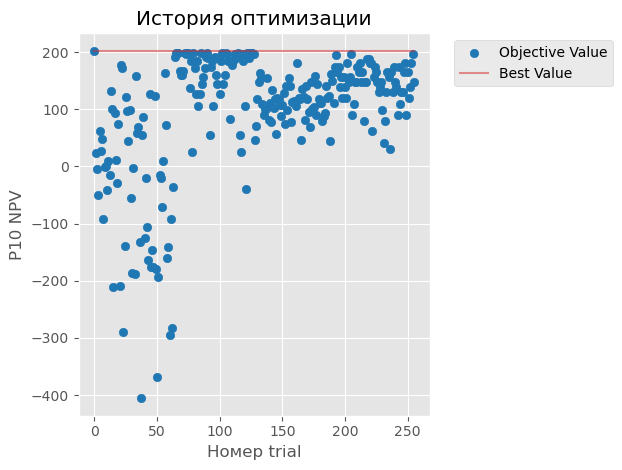

In [9]:
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour
)
plt.rcParams["font.family"] = "DejaVu Sans"
trials_df = study.trials_dataframe()

fig = plot_optimization_history(study)
plt.title("История оптимизации")
plt.xlabel("Номер trial")
plt.ylabel("P10 NPV")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_9184\3570387172.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = plot_contour(


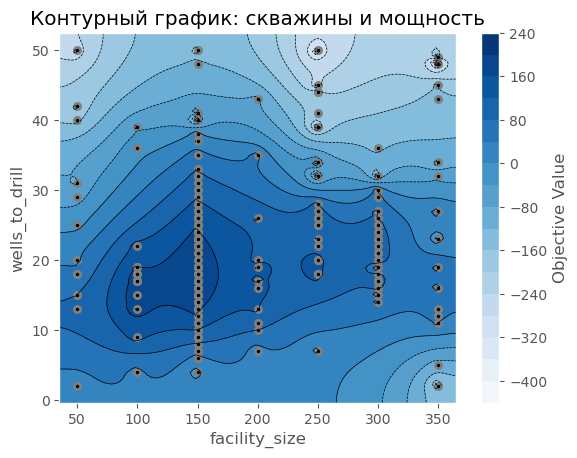

In [12]:
fig = plot_contour(
    study,
    params=["wells_to_drill", "facility_size"]
)
plt.title("Контурный график: скважины и мощность")
plt.show()

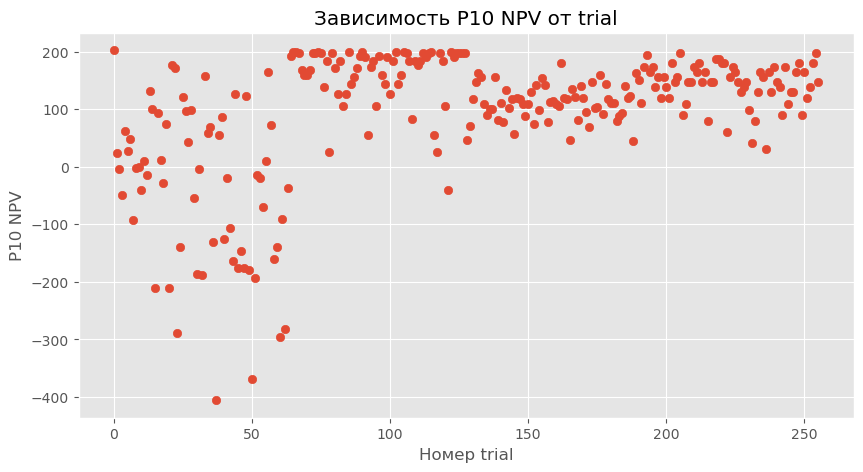

In [13]:
plt.figure(figsize=(10,5))

plt.scatter(
    trials_df["number"],
    trials_df["value"]
)
plt.xlabel("Номер trial")
plt.ylabel("P10 NPV")
plt.title("Зависимость P10 NPV от trial")
plt.grid(True)
plt.show()

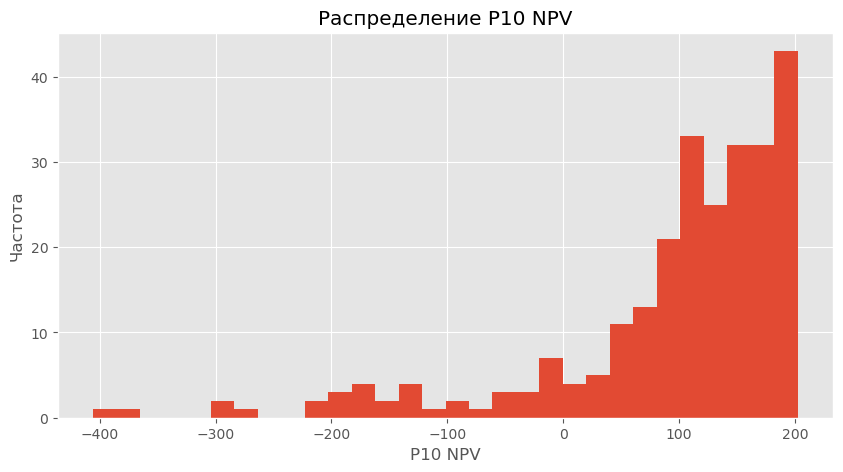

In [14]:
plt.figure(figsize=(10,5))

plt.hist(
    trials_df["value"],
    bins=30
)
plt.xlabel("P10 NPV")
plt.ylabel("Частота")
plt.title("Распределение P10 NPV")
plt.grid(True)
plt.show()

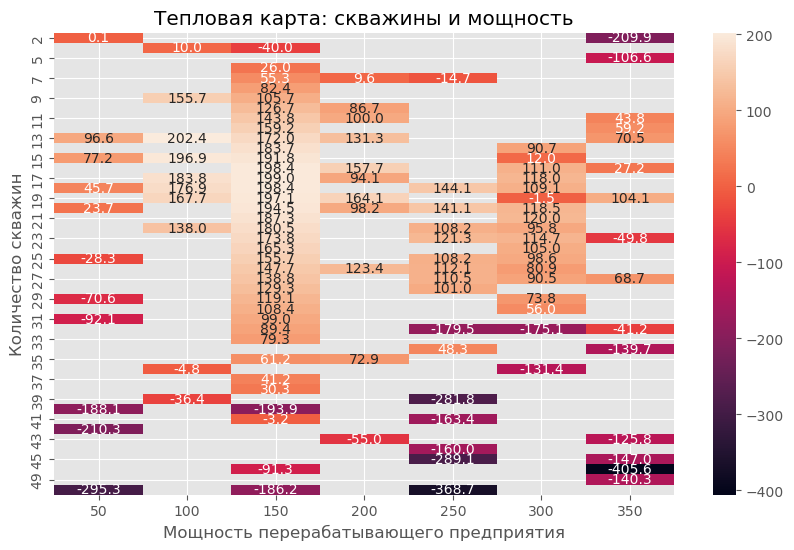

In [15]:
pivot = trials_df.pivot_table(
    values="value",
    index="params_wells_to_drill",
    columns="params_facility_size",
    aggfunc="max"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f"
)
plt.title("Тепловая карта: скважины и мощность")
plt.xlabel("Мощность перерабатывающего предприятия"
plt.ylabel("Количество скважин")
plt.show()

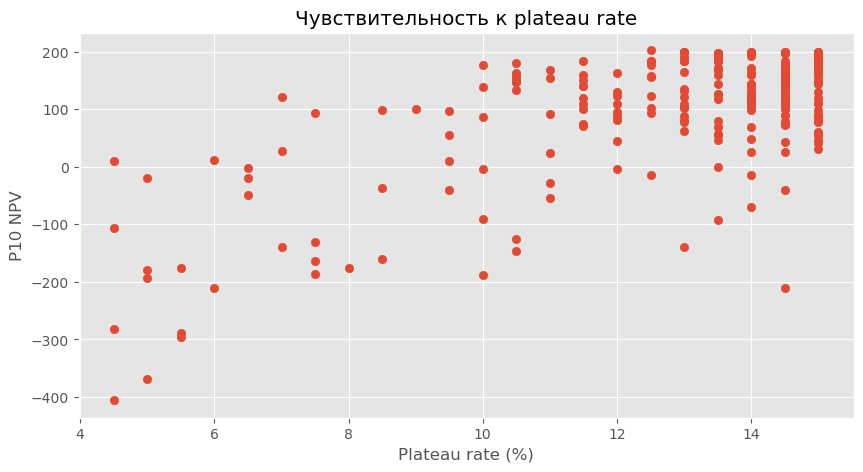

In [16]:
plt.figure(figsize=(10,5))

plt.scatter(
    trials_df["params_plateau_rate_is"],
    trials_df["value"]
)
plt.xlabel("Plateau rate (%)")
plt.ylabel("P10 NPV")
plt.title("Чувствительность к plateau rate"
plt.grid(True)
plt.show()

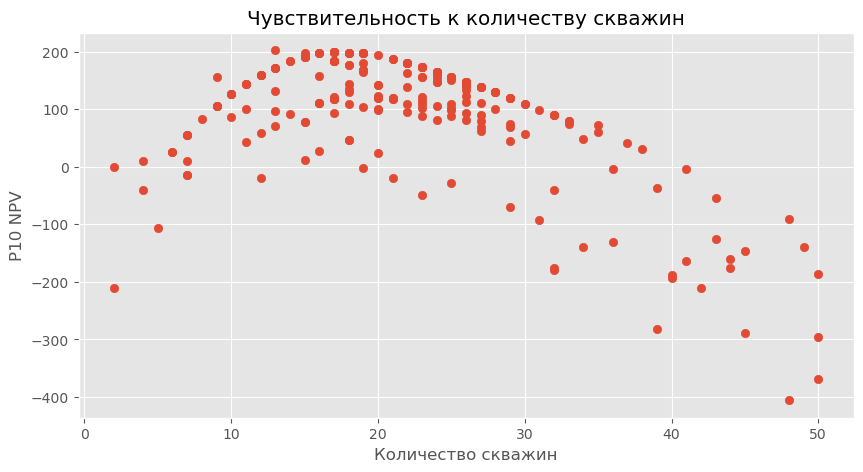

In [17]:
plt.figure(figsize=(10,5))

plt.scatter(
    trials_df["params_wells_to_drill"],
    trials_df["value"]
)
plt.xlabel("Количество скважин")
plt.ylabel("P10 NPV"
plt.title("Чувствительность к количеству скважин")
plt.grid(True)
plt.show()

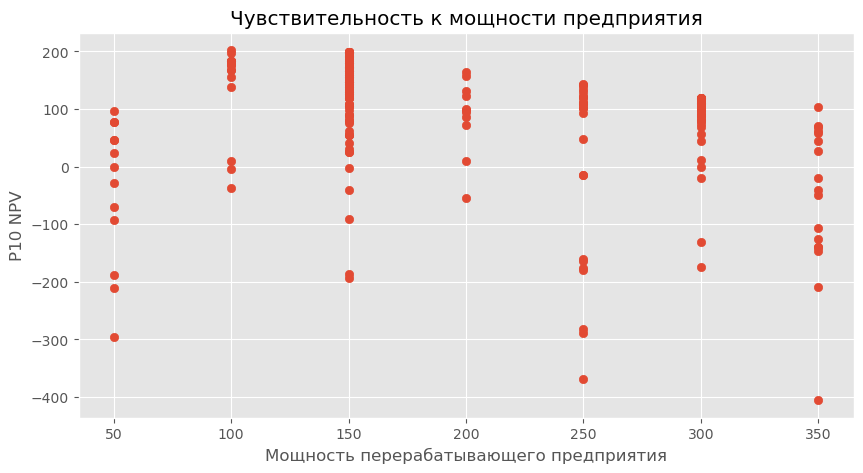

In [18]:
plt.figure(figsize=(10,5))

plt.scatter(
    trials_df["params_facility_size"],
    trials_df["value"]

plt.xlabel("Мощность перерабатывающего предприятия")
plt.ylabel("P10 NPV")
plt.title("Чувствительность к мощности предприятия")
plt.grid(True)
plt.show()

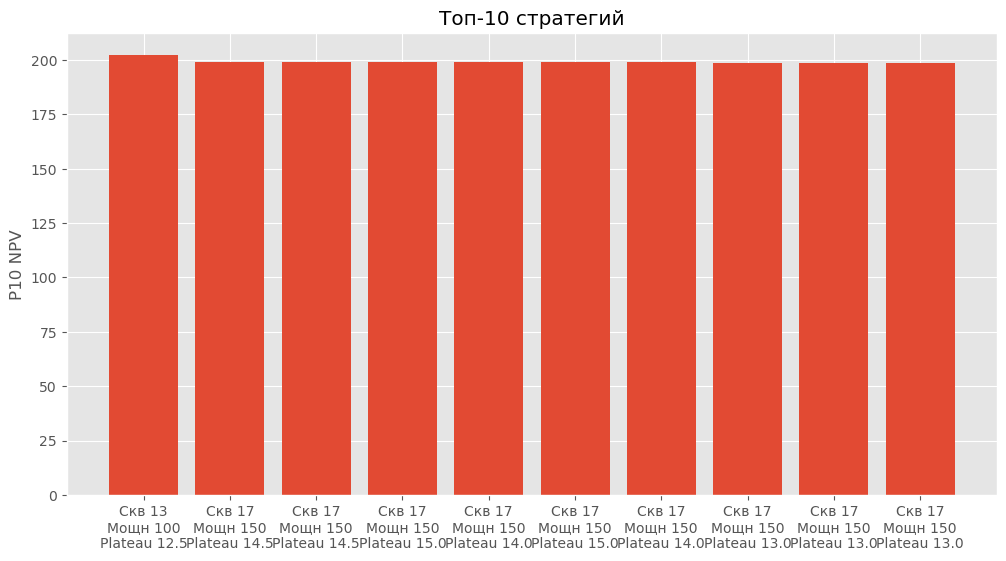

In [19]:
top10 = trials_df.sort_values(
    "value",
    ascending=False
).head(10)
plt.figure(figsize=(12,6))

plt.bar(
    range(len(top10)),
    top10["value"]
)
plt.xticks(
    range(len(top10)),
    [
        f"Скв {w}\nМощн {f}\nPlateau {p}"
        for w, f, p in zip(
            top10["params_wells_to_drill"],
            top10["params_facility_size"],
            top10["params_plateau_rate_is"]
        )
    ]
)
plt.ylabel("P10 NPV")
plt.title("Топ-10 стратегий")
plt.show()

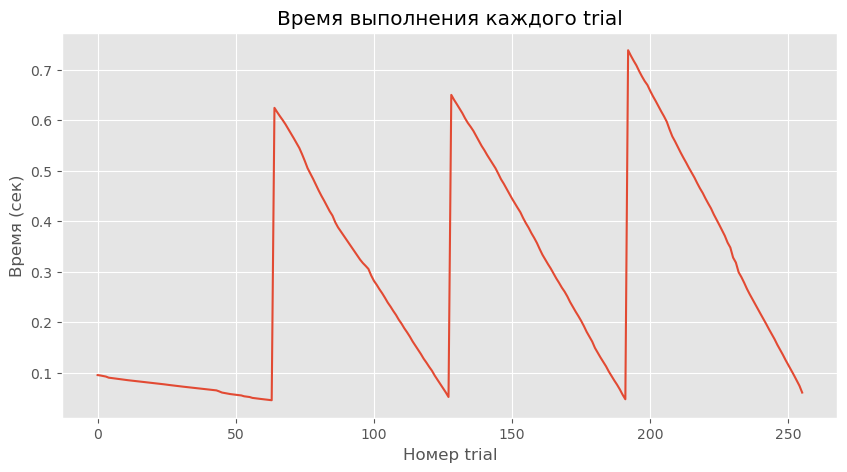

In [20]:
durations = [
    t.duration.total_seconds()
    for t in study.trials
]
plt.figure(figsize=(10,5))
plt.plot(durations)
plt.xlabel("Номер trial")
plt.ylabel("Время (сек)")
plt.title("Время выполнения каждого trial")
plt.grid(True)
plt.show()

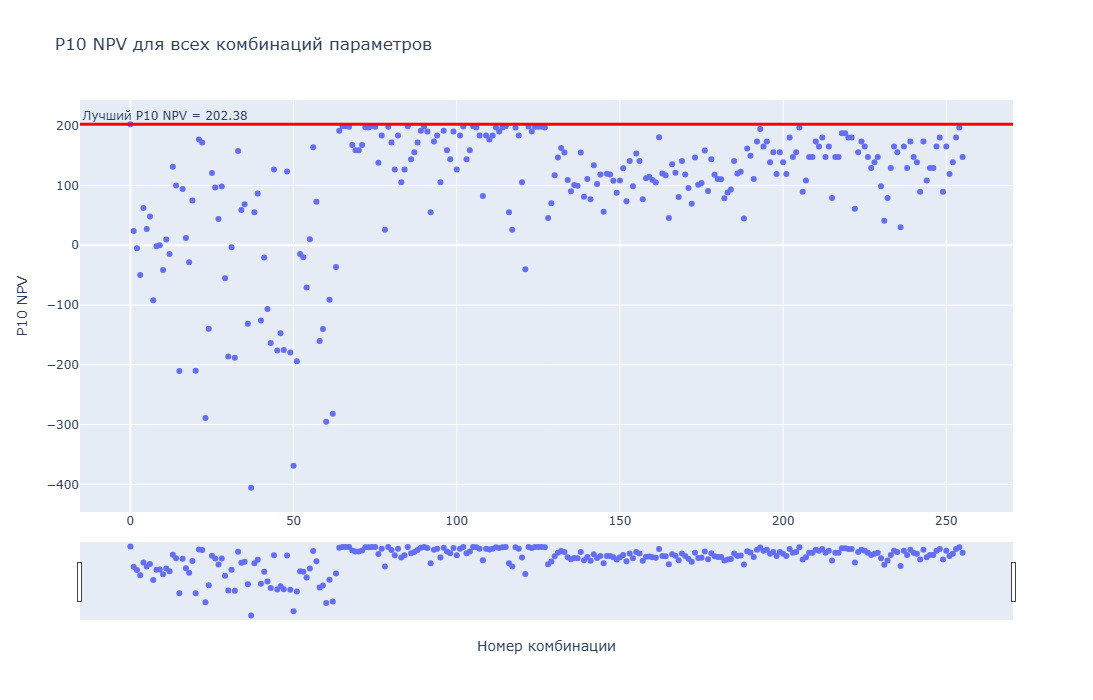

In [30]:
import plotly.express as px

# dataframe из optuna
trials_df = study.trials_dataframe()

# номер комбинации
trials_df["combo_id"] = range(len(trials_df))

# лучший P10 NPV из Optuna
best_npv = study.best_value

# интерактивный график
fig = px.scatter(
    trials_df,
    x="combo_id",
    y="value",

    hover_data={
        "params_wells_to_drill": True,
        "params_facility_size": True,
        "params_plateau_rate_is": True,
        "combo_id": False
    },

    title="P10 NPV для всех комбинаций параметров"
)

# красная линия лучшего результата
fig.add_hline(
    y=best_npv,
    line_color="red",
    line_width=3,
    annotation_text=f"Лучший P10 NPV = {best_npv:.2f}",
    annotation_position="top left"
)

# оформление
fig.update_layout(
    xaxis_title="Номер комбинации",
    yaxis_title="P10 NPV",
    height=700
)

# ползунок
fig.update_xaxes(
    rangeslider_visible=True
)

fig.show()

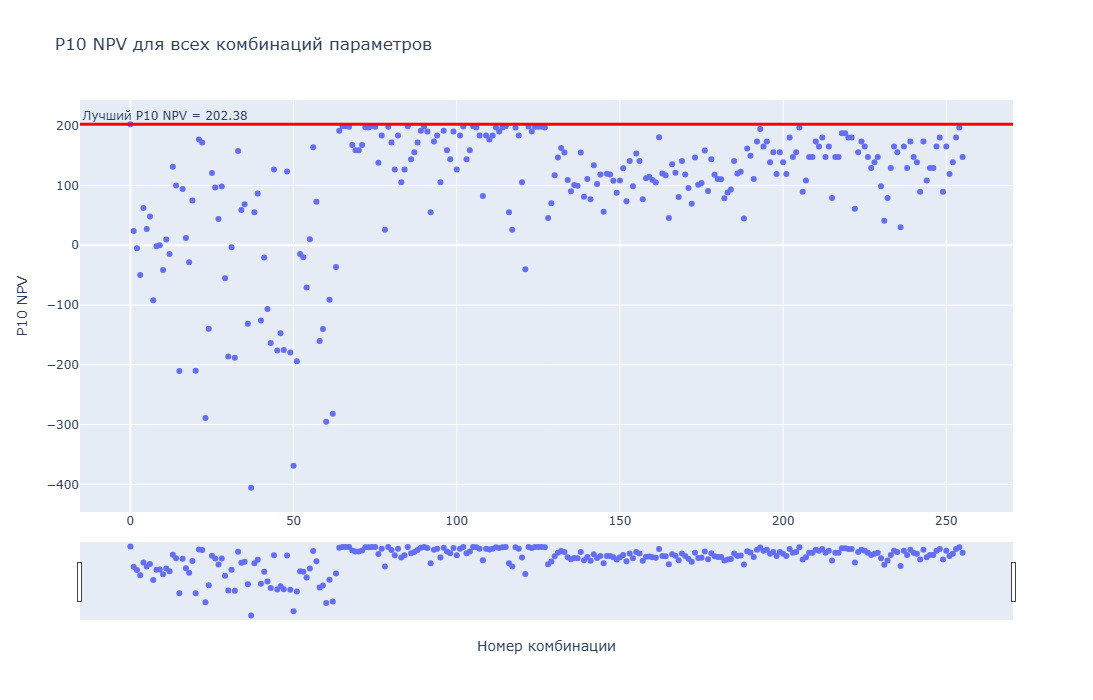

In [31]:
import plotly.express as px

# dataframe
trials_df = study.trials_dataframe()

# номер комбинации
trials_df["combo_id"] = range(len(trials_df))

# лучший NPV из первого блока
best_npv = study.best_trial.value

# график
fig = px.scatter(
    trials_df,
    x="combo_id",
    y="value",

    hover_data={
        "params_wells_to_drill": True,
        "params_facility_size": True,
        "params_plateau_rate_is": True,
        "combo_id": False
    },

    title="P10 NPV для всех комбинаций параметров"
)

# красная линия
fig.add_hline(
    y=best_npv,
    line_color="red",
    line_width=3,
    annotation_text=f"Лучший P10 NPV = {best_npv:.2f}",
    annotation_position="top left"
)

# оформление
fig.update_layout(
    xaxis_title="Номер комбинации",
    yaxis_title="P10 NPV",
    height=700
)

# ползунок
fig.update_xaxes(
    rangeslider_visible=True
)

fig.show()